<a href="https://colab.research.google.com/github/vani-analytics/vani-first/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name -**  

##### **Project Type**    - Unsupervised learning
##### **Project Name**    - Customer segmentation using Machine Learning

# Import Libraries

In [1]:
import pandas as pd

# Load Data

In [3]:
data=pd.read_csv("/content/Mall_Customers.csv")

# First 5 records

In [4]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Last 5 records

In [5]:
data.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


# Number of rows and columns

In [6]:
data.shape

(200, 5)

In [7]:
print("Number of Rows",data.shape[0])
print("Number of Columns",data.shape[1])

Number of Rows 200
Number of Columns 5


# Dataset Information

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Check Null values

In [9]:
data.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


# Get overall statistics about the datataset

In [10]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Kmeans Clustering

In [11]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [12]:
X=data[['Annual Income (k$)','Spending Score (1-100)']]

In [13]:
from sklearn.cluster import KMeans

In [14]:
k_means=KMeans()
k_means.fit(X) #Fit() - To train the KMeans clustering

KMeans()

In [15]:
k_means=KMeans()
k_means.fit_predict(X) #fit_predict()- not only train but also create a new dependent variable

array([3, 4, 7, 4, 3, 4, 7, 4, 7, 4, 7, 4, 7, 4, 7, 4, 3, 4, 7, 4, 3, 4,
       7, 4, 7, 4, 3, 4, 3, 4, 7, 4, 7, 4, 7, 4, 7, 4, 3, 4, 3, 4, 3, 3,
       3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2,
       3, 3, 2, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 6, 1, 6, 1, 0, 1, 0, 1,
       6, 1, 0, 1, 0, 1, 0, 1, 0, 1, 6, 1, 0, 1, 6, 1, 6, 1, 0, 1, 6, 1,
       0, 1, 0, 1, 0, 1, 6, 1, 0, 1, 6, 1, 0, 1, 6, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 5, 6, 5, 0, 5, 6, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5,
       0, 5], dtype=int32)

# **Elbow method to find optimal number of clusters**

In [16]:
wcss=[]
for i in range(1,11):
  k_means=KMeans(n_clusters=i)
  k_means.fit(X)
  wcss.append(k_means.inertia_)

In [17]:
wcss

[269981.28000000014,
 184740.39627314542,
 106348.37306211119,
 73880.64496247198,
 44448.45544793369,
 38797.9027638142,
 33870.80058476308,
 29893.521011933182,
 23397.954595259802,
 19762.508813384113]

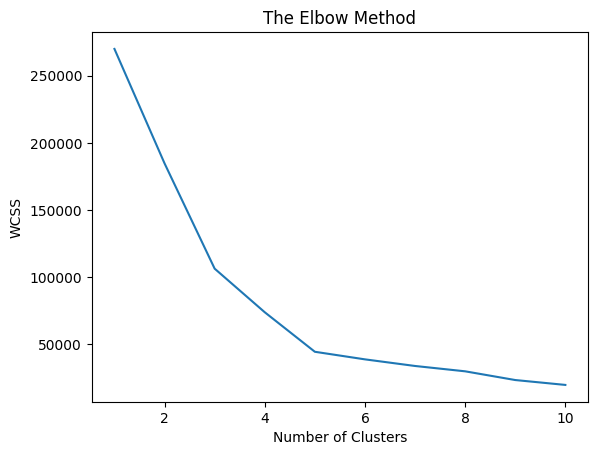

In [18]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# **Model training**

In [19]:
X=data[['Annual Income (k$)','Spending Score (1-100)']]

In [20]:
k_means=KMeans(n_clusters=5,random_state=42)
y_predict=k_means.fit_predict(X)

In [21]:
y_predict

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

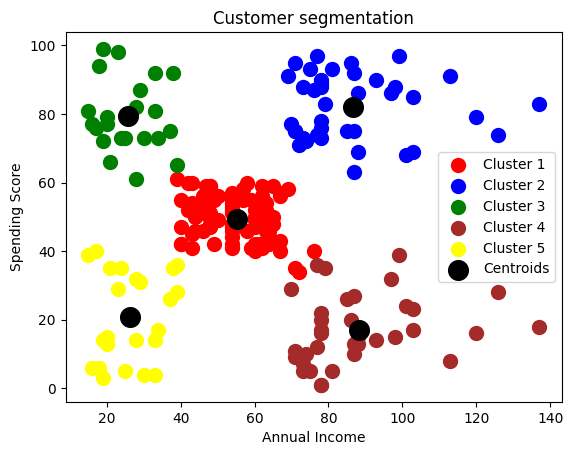

In [22]:
plt.scatter(X.iloc[y_predict==0,0],X.iloc[y_predict==0,1],s=100,c='red',label="Cluster 1")
plt.scatter(X.iloc[y_predict==1,0],X.iloc[y_predict==1,1],s=100,c='blue',label="Cluster 2")
plt.scatter(X.iloc[y_predict==2,0],X.iloc[y_predict==2,1],s=100,c='green',label="Cluster 3")
plt.scatter(X.iloc[y_predict==3,0],X.iloc[y_predict==3,1],s=100,c='brown',label="Cluster 4")
plt.scatter(X.iloc[y_predict==4,0],X.iloc[y_predict==4,1],s=100,c='yellow',label="Cluster 5")
plt.scatter(k_means.cluster_centers_[:,0],k_means.cluster_centers_[:,1],s=200,c='black',label="Centroids")
plt.title("Customer segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()

In [24]:
k_means.predict([[13,12]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

### Explaination about the graph

Cluster 1- Customers with medium annual income spents meadium

Cluster 5- Customers with low annual income spents low

Cluster 3- Customers with low annual income spents high

Cluster 4- Customers with high annual income spents low

Cluster 2- Customers with high annual income spents high





## **Save the Model**

In [25]:
import joblib

In [26]:
joblib.dump(k_means,"customer segmantation")  #To save our model

['customer segmantation']

In [27]:
model=joblib.load("customer segmantation")

In [28]:
model.predict([[13,12]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([4], dtype=int32)